In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [ ]:

# =====================
# DATA
# =====================
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 39.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.08MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.21MB/s]


In [ ]:
# =====================
# VAE MODEL
# =====================
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 2)       # latent dim = 2
        self.fc_logvar = nn.Linear(400, 2)

        self.fc3 = nn.Linear(2, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [ ]:

# =====================
# LOSS
# =====================
def loss_fn(recon, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KL

In [ ]:

# =====================
# TRAIN
# =====================
for epoch in range(5):
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 784)

        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss}")


In [ ]:
#=====================
# LATENT SPACE VISUALIZATION
# =====================
import numpy as np

z_list = []
labels = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.view(-1, 784)
        mu, _ = model.encode(x)
        z_list.append(mu)
        labels.append(y)

z = torch.cat(z_list).numpy()
labels = torch.cat(labels).numpy()


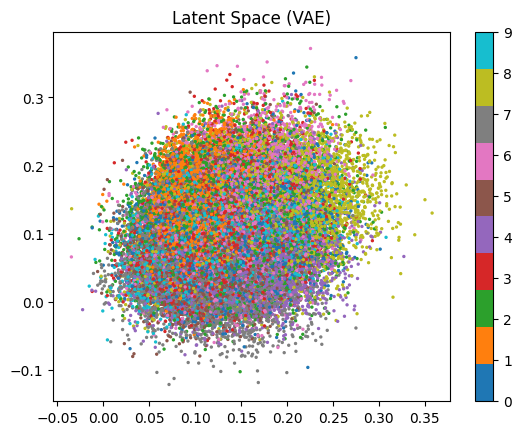

In [ ]:

plt.scatter(z[:,0], z[:,1], c=labels, cmap='tab10', s=2)
plt.colorbar()
plt.title("Latent Space (VAE)")
plt.show()